# FR3 Cartesian-impedance surface following

This is a compact simulation version of `trackpy/run_track.ipynb`. The static STL rail has real collision geometry. The controller approaches it, detects contact from persistent pose-reference error, and follows its curved upper surface using tangent-aligned Cartesian compliance.

Run the cells in order. The final cleanup cell removes preload and retreats.

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rclpy

sys.path.insert(0, '/opt/demo/scripts')
from robotblockset.ros2.franka_ros2 import fr3
from surface_ros_common import wait_for_fr3_graph
from surface_following import (
    SurfaceConfig, move_to_safe_start, approach_until_contact,
    follow_surface, retreat, validate_run,
)

config = SurfaceConfig(fixture_base_z=float(os.getenv('FIXTURE_BASE_Z', '0.55')))
config

SurfaceConfig(fixture_x=0.38, fixture_base_z=0.55, start_x=0.4, center_y=0.0, tool_quaternion_wxyz=(0.0, -0.9238795, 0.3826834, 0.0), fixture_surface_start_y=-0.0221, probe_radius=0.025, safe_clearance=0.03, approach_step=0.001, approach_limit=0.06, contact_error=0.003, contact_samples=3, travel=0.18, tangent_lead=0.01, tangent_filter_gain=0.15, tangent_window_samples=25, tangent_min_window_progress=0.001, tangent_min_x=0.87, sample_period=0.02, max_follow_time=90.0, penetration_bias=0.005, tangent_stiffness=1200.0, lateral_stiffness=1200.0, normal_stiffness=80.0, approach_normal_stiffness=1200.0, rotational_stiffness=25.0, preload=4.0, max_tracking_error=0.045, max_lateral_error=0.012)

In [2]:
if not rclpy.ok():
    rclpy.init()
wait_for_fr3_graph('', timeout=90.0)
robot = fr3(control_strategy='CartesianImpedance', SIM=True)
robot.SetLogLevel('ERROR', logger='Python')
robot.GetState()
print('Connected. Current pose:', np.round(robot.x, 4))

ROS preflight passed: /controller_manager/list_controllers, /joint_states


[INFO] [1789457401.114634148] [fr3]: Waiting for controller_manager lifecycle services ...
[INFO] [1789457401.115859321] [fr3]: Lifecycle helper connected.
[INFO] [1789457401.116590995] [fr3]: Subscribing to joint states topic: /joint_states
[INFO] [1789457401.170828446] [fr3]: Connected
[INFO] [1789457401.289491009] [fr3]: Activated RosControllerInterface


Connected. Current pose: [ 0.3079  0.0618  0.5900 -0.0067 -0.9155  0.4022  0.0000]


## Motion acknowledgement
Set `RUN_MOTION = True` only after Gazebo shows the fixture and robot correctly. This notebook controls simulation only (`SIM=True`).

In [3]:
robot.x

array([ 0.3079,  0.0618,  0.5900, -0.0067, -0.9155,  0.4022,  0.0000])

In [4]:
RUN_MOTION = True
assert RUN_MOTION, 'Inspect Gazebo, then change RUN_MOTION to True.'
safe_pose = move_to_safe_start(robot, config)
print('Safe start:', np.round(safe_pose, 4))

Lift clear of fixture: Trajectory execution successful
Move above fixture start: Trajectory execution successful
Safe start: [ 0.4013 -0.0758  0.5945 -0.0118 -0.9093  0.4159 -0.0016]


In [5]:
robot.CMove(robot.x,t=1.0)

0

In [6]:
robot.SetCartesianStiff()

0

In [7]:
robot.GetTCP()

array([[ 1.0000,  0.0000,  0.0000,  0.0000],
       [ 0.0000,  1.0000,  0.0000,  0.0000],
       [ 0.0000,  0.0000,  1.0000,  0.0000],
       [ 0.0000,  0.0000,  0.0000,  1.0000]])

In [8]:
# Position beside the fixture with 3 cm lateral clearance.
# Default flange target: [0.40, -0.0771, 0.595] m; preserve orientation.
assert RUN_MOTION, 'Enable motion only after inspecting Gazebo.'
robot.GetState()
assert robot.x[2] > config.fixture_base_z, 'Reset Gazebo and reconnect after a collapse before running this cell.'
safe_pose = move_to_safe_start(robot, config, duration=8.0)
print('Beside fixture:', np.round(safe_pose, 4))

Lift clear of fixture: Trajectory execution successful
Move above fixture start: Trajectory execution successful
Beside fixture: [ 0.4002 -0.0769  0.5951 -0.0132 -0.9068  0.4214 -0.0011]


Contact detected after 0.036 m approach (normal tracking error 0.0059 m).
Contact travel: 0.036000000000000025


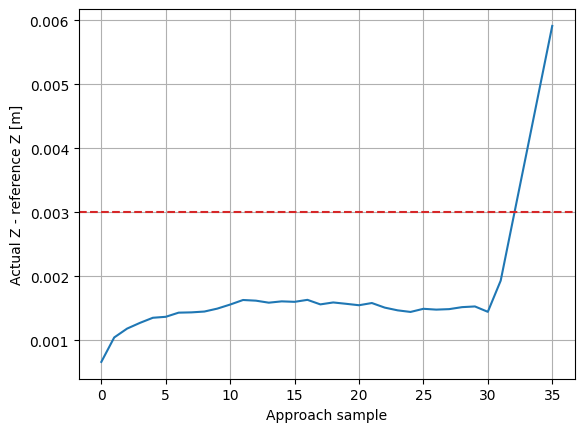

In [9]:
contact = approach_until_contact(robot, config)
print('Contact travel:', contact['travel'])
plt.plot(contact['normal_errors'])
plt.axhline(config.contact_error, color='tab:red', linestyle='--')
plt.xlabel('Approach sample'); plt.ylabel('Actual Z - reference Z [m]'); plt.grid();

In [10]:
data = follow_surface(robot, contact['target'], config)
metrics = validate_run(data, config)
np.savez('/opt/demo/notebooks/surface_run.npz', **data)
metrics

track step=0 progress=0.0003 m actual=[ 0.4036 -0.0467  0.5922] reference=[ 0.4132 -0.0417  0.5922]
Surface traversal completed at step 147: euclidean displacement=0.1802 m


{'progress': 0.179889665957064,
 'y_span': 0.02300765670427246,
 'max_tracking_error': 0.010875450973646556}

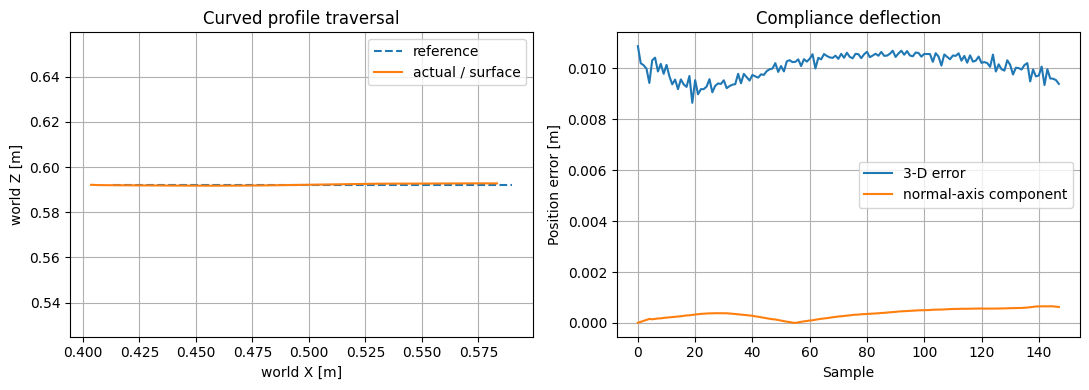

In [11]:
p = data['positions'][:, :3]
pr = data['reference_poses'][:, :3]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(pr[:, 0], pr[:, 2], '--', label='reference')
ax[0].plot(p[:, 0], p[:, 2], label='actual / surface')
ax[0].set(xlabel='world X [m]', ylabel='world Z [m]', title='Curved profile traversal')
ax[0].axis('equal'); ax[0].grid(); ax[0].legend()
ax[1].plot(np.linalg.norm(data['tracking_errors'], axis=1), label='3-D error')
ax[1].plot(np.abs(data['tracking_errors'][:, 2]), label='normal-axis component')
ax[1].set(xlabel='Sample', ylabel='Position error [m]', title='Compliance deflection')
ax[1].grid(); ax[1].legend(); fig.tight_layout()

In [12]:
retreat(robot)
robot.StopMotion()
robot.Shutdown()
if rclpy.ok():
    rclpy.shutdown()
print('Retreated and shut down cleanly.')

Retreat from fixture: Trajectory execution successful
Retreated and shut down cleanly.


[INFO] [1789457455.251143931] [fr3]: Waiting for ROS2 spin thread to finish...
[INFO] [1789457455.251788055] [fr3]: Shutting down control helper...
[INFO] [1789457455.258185679] [fr3]: Removing node from executor...
[INFO] [1789457455.258589087] [fr3]: Shutting down executor...
[INFO] [1789457455.259093895] [fr3]: Destroying node...


In [ ]:
great